In [1]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# show pwd
import os
print(os.getcwd())


/home/zama/reps/TFG_Matematicas/code/compression


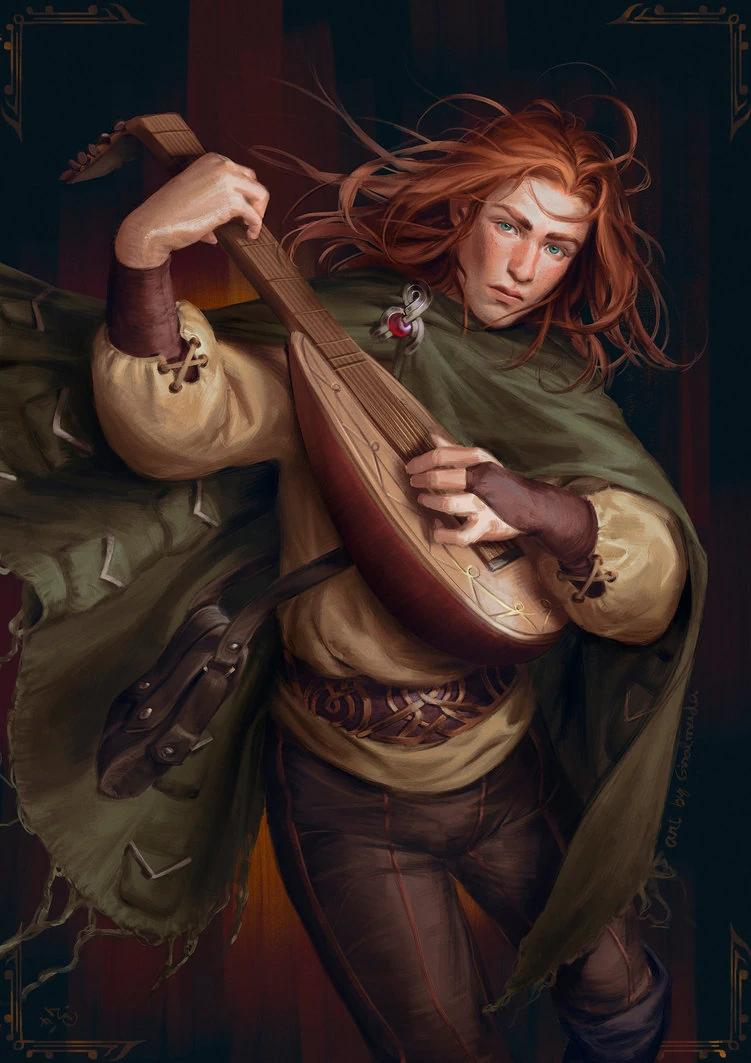

In [3]:
img = Image.open('kvothe.jpg')
display(img)
image_array = np.array(img)

In [4]:
db0 = np.array([0.7071067812, 0.7071067812])
db1 = np.array([0.7071067812, 0.7071067812])
db2 = np.array([-0.1294095226, 0.2241438680, 0.8365163037, 0.4829629131])
db3 = np.array([0.0352262919, -0.0854412739, -0.1350110200, 0.4598775021, 0.8068915093, 0.3326705529])

In [5]:
low_pass = db0

Dado el filtro de paso bajo, calculamos el filtro de paso alto: <br>
$\beta_n = (-1)^{n+1}\overline{\alpha_{1-n}}$

In [6]:
#TODO: CAMBIAR

high_pass = low_pass[::-1]
high_pass[::2] *= -1
high_pass

array([-0.70710678,  0.70710678])

$c_{j-1,k} = \sqrt{2} \sum_{n \in \mathbb{Z}} \overline{\alpha_n} c_{j,2k-n}$

In [7]:
def apply_deconstruction(signal, filter, not_real=False):

    filter_copy = np.copy(filter)

    if not_real:
        filter_copy = np.conj(filter)
    
    #filter_copy *= np.sqrt(2)

    #Convolucion entre señal y filtro
    dd = np.convolve(signal, filter_copy)

    #Downsampling
    dd = dd[1::2]

    return dd

$c_{j,l} = \sqrt{2} \sum_{k \in \mathbb{Z}} c_{j-1,k}\alpha_{2k-l}+d_{j-1,k}\beta_{2k-l}$

In [8]:
def apply_construction(coefficients, details, _low_pass, _high_pass):

        low_pass = np.copy(_low_pass)
        high_pass = np.copy(_high_pass)
        
        cc = np.zeros(2*len(coefficients))
        cc[::2] = np.copy(coefficients)

        dd = np.zeros(2*len(details))
        dd[::2] = np.copy(details)

        reconstruct = np.convolve(cc, low_pass[::-1]) + np.convolve(dd, high_pass[::-1])

        reconstruct *= np.sqrt(2)
        
        return reconstruct[:-1]
        
        


In [9]:
#TODO: alpha_n vs low_pass
def get_ck_lower_resolution(low_pass, signal, not_real=False):

    if not_real:
        low_pass = np.conj(low_pass)
    low_pass *= np.sqrt(2)

    #Convolución entre las secuencias low_pass y signal
    ck = np.convolve(low_pass, signal)
    
    #Downsampling
    ck = ck[1::2]

    return ck

$d_{j-1,k} = \sqrt{2} \sum_{n \in \mathbb{Z}} \overline{\beta_n} c_{j,2k-n}$

In [10]:
def get_dk_lower_resolution(high_pass, signal, not_real=False):

    if not_real:
        high_pass = np.conj(high_pass)

    dk = np.zeros(len(signal)//2)
    for k in range(len(dk)):
        dk[k] = np.sum(np.sqrt(2) * high_pass * signal[2*k:2*k+len(high_pass)])
    return dk

In [11]:
lp = np.array([1/2, 1/2])
hp = np.array([-1/2, 1/2])
signal = np.array([1, 1, 1, 1, 2, 3, 2, 3, 4, 5, 5, 4, 6, 6, 6, 6])

In [12]:
def ck_haar(signal):
    new = np.zeros(len(signal)//2)
    for i in range(len(new)):
        new[i] = (signal[2*i] + signal[2*i+1])/np.sqrt(2)
        #print(i, signal[2*i], signal[2*i+1], new[i])
    return new

In [13]:
def construct_haar(c,d):
    new = np.zeros(2*len(c))
    for i in range(len(c)):
        new[2*i] = (c[i] + d[i])/np.sqrt(2)
        new[2*i+1] = (c[i] - d[i])/np.sqrt(2)
    return new

In [14]:
ck_haar(signal)*1/np.sqrt(2)

array([1. , 1. , 2.5, 2.5, 4.5, 4.5, 6. , 6. ])

In [15]:
def get_hig_pass(_low_pass):
    low_pass = np.copy(_low_pass)
    high_pass = low_pass[::-1]
    high_pass[::2] *= -1
    return high_pass

In [16]:
c1 =apply_deconstruction(signal, db2)

d1 =apply_deconstruction(signal, get_hig_pass(db2))
c1, d1

(array([ 0.1339746 ,  2.        ,  1.95096189,  5.        ,  5.26794919,
         9.5       ,  8.95096189, 12.        , 11.19615242]),
 array([ 5.00000000e-01, -1.11022302e-16, -1.83012702e-01, -1.00000000e+00,
         1.41421097e-10,  8.66025404e-01,  8.16987298e-01,  0.00000000e+00,
        -3.00000000e+00]))

In [17]:
apply_construction(c1, d1, db2, get_hig_pass(db2))/2

array([-6.61517341e-11, -6.61517341e-11,  1.00000000e+00,  1.00000000e+00,
        1.00000000e+00,  1.00000000e+00,  2.00000000e+00,  3.00000000e+00,
        2.00000000e+00,  3.00000000e+00,  4.00000000e+00,  5.00000000e+00,
        5.00000000e+00,  4.00000000e+00,  6.00000000e+00,  6.00000000e+00,
        6.00000000e+00,  6.00000000e+00, -3.96910267e-10, -3.96910424e-10])

In [18]:
apply_construction(c1, d1, lp, hp)

array([ 0.44828774, -0.25881905,  1.41421356,  1.41421356,  1.25012886,
        1.50894791,  2.82842712,  4.24264069,  3.7250026 ,  3.7250026 ,
        7.32988686,  6.10514198,  6.90698311,  5.75158859,  8.48528137,
        8.48528137,  5.79555496, 10.03819564])

In [19]:
c1 = apply_deconstruction(signal, db1/np.sqrt(2))
d1 = apply_deconstruction(signal, db1/np.sqrt(2))

In [20]:
# Prueba con daubechie 2

low_pass = db2/np.sqrt(2)
low_pass

array([-0.09150635,  0.15849365,  0.59150635,  0.34150635])

In [23]:
db2 
h2 = get_hig_pass(db2)
h2

array([-0.48296291,  0.8365163 , -0.22414387, -0.12940952])

In [26]:
import pywt
x = [1, 1, 1, 1, 2, 3, 2, 3, 4, 5, 5, 4, 6, 6, 6, 6]
cA, cD = pywt.dwt(x, 'db2')
print(cA)

[1.41421356 1.41421356 1.37953839 3.53553391 3.7250026  6.71751442
 6.32928585 8.48528137 8.48528137]


In [31]:
ccA, ccD = pywt.dwt(x, 'db1')
print(ccA)

[1.41421356 1.41421356 3.53553391 3.53553391 6.36396103 6.36396103
 8.48528137 8.48528137]


In [33]:
c1 = apply_deconstruction(signal, db1)
(c1/2)*np.sqrt(2)

array([1.41421356, 1.41421356, 3.53553391, 3.53553391, 6.36396103,
       6.36396103, 8.48528137, 8.48528137])

In [46]:
dd = np.convolve(signal, db2)
dd = dd[2::2]
dd = dd[:-1]
dd


array([0.93125065, 1.28480404, 2.56960808, 3.27671486, 5.26862568,
       6.71751442, 7.51935555, 9.26173851])

In [48]:
db2h = get_hig_pass(db2)

c1 = db2h[0]*signal[2] + db2h[1]*signal[1] + db2h[2]*signal[0]
c2 = db2h[0]*signal[4] + db2h[1]*signal[3] + db2h[2]*signal[2] + db2h[3]*signal[1]
c1, c2  

(0.12940952259999997, -0.4829629131)

In [47]:
di = np.convolve(signal, get_hig_pass(db2))
di = di[2::2]
di = di[:-1]
di

array([ 0.12940952, -0.48296291,  0.96592583, -0.25881905,  0.48296291,
       -1.31947922,  0.25881905,  2.89777748])

In [49]:
apply_construction(dd,di, db2, get_hig_pass(db2))

array([ 0.61237244,  1.06066017,  1.41421356,  1.41421356,  1.41421356,
        2.82842712,  4.24264069,  2.82842712,  4.24264069,  5.65685425,
        7.07106781,  7.07106781,  5.65685425,  8.48528137,  8.48528137,
        8.48528137,  6.36396103, -3.67423461])